In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("iris")

display(df.head())
print("Shape:", df.shape)
print(df.dtypes)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


# Phần 1 — Thống kê mô tả & đặc trưng

In [24]:
numeric_df = df.select_dtypes(include="number")
numeric_df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [25]:
mean_values = numeric_df.mean()
median_values = numeric_df.median()
mode_values = numeric_df.mode()
var_values = numeric_df.var()
std_values = numeric_df.std()
min_values = numeric_df.min()
max_values = numeric_df.max()
q1_values = numeric_df.quantile(0.25)
q3_values = numeric_df.quantile(0.75)
iqr_values = q3_values - q1_values

summary_df = pd.DataFrame({
    "mean": mean_values,
    "median": median_values,
    "var": var_values,
    "std": std_values,
    "min": min_values,
    "max": max_values,
    "q1": q1_values,
    "q3": q3_values,
    "iqr": iqr_values,
})
display(summary_df)

,mean,median,var,std,min,max,q1,q3,iqr
sepal_length,5.843333,5.80,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057333,3.00,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
petal_length,3.758000,4.35,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
petal_width,1.199333,1.30,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


In [26]:
group_stats = df.groupby("species")[numeric_df.columns].agg(["mean", "std"])
display(group_stats)

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

# Phần 2 — Phân phối xác suất

In [27]:
display(list(df["species"].unique()))

category = list(df["species"].unique())

['setosa', 'versicolor', 'virginica']

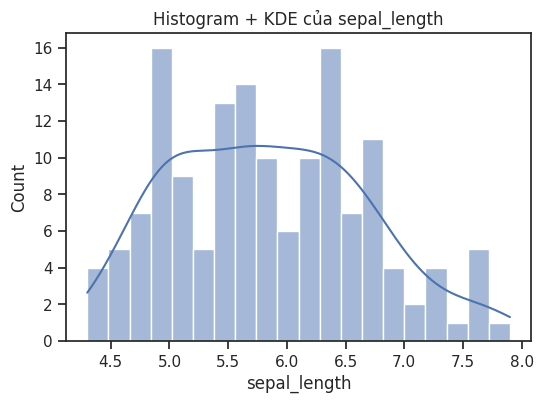

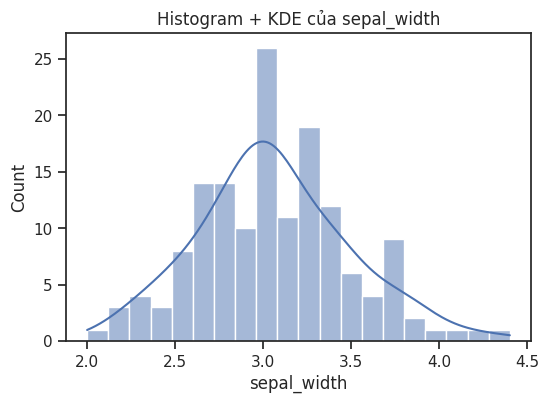

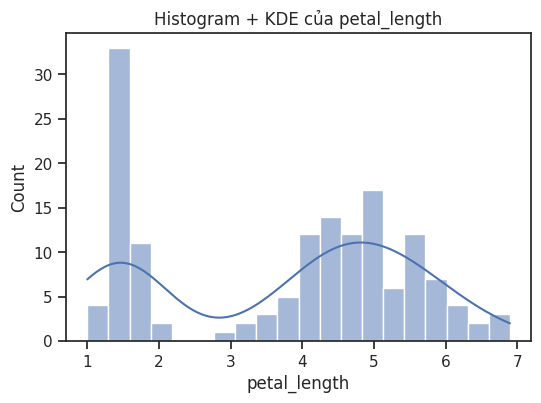

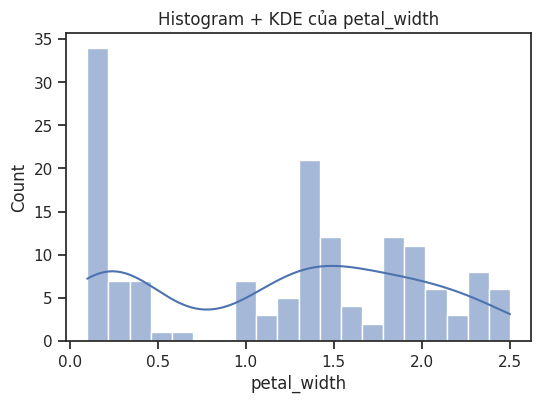

In [28]:
numeric_cols = df.select_dtypes(include="number").columns
for col in numeric_cols:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=20
    )

    plt.title(f"Histogram + KDE của {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

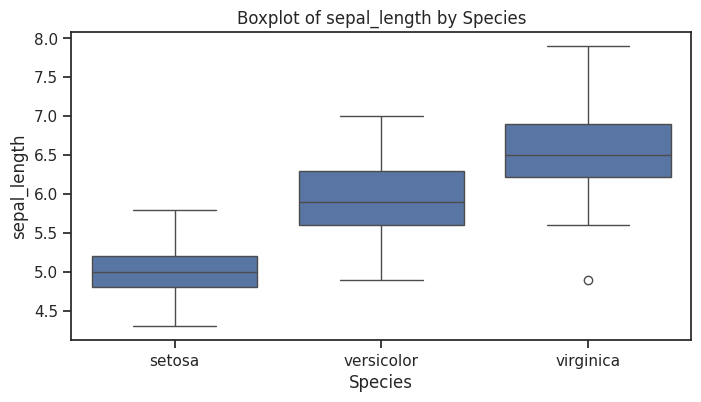

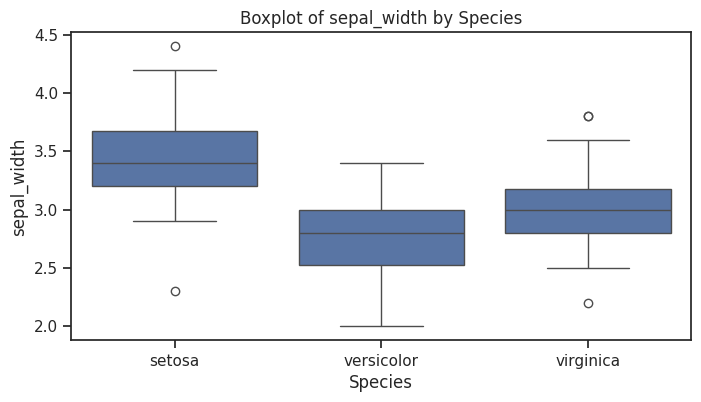

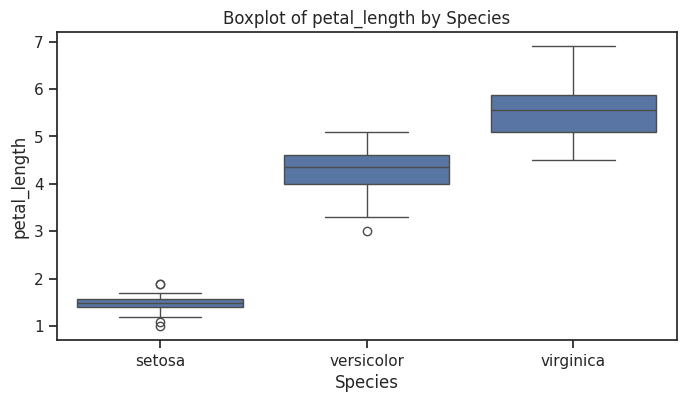

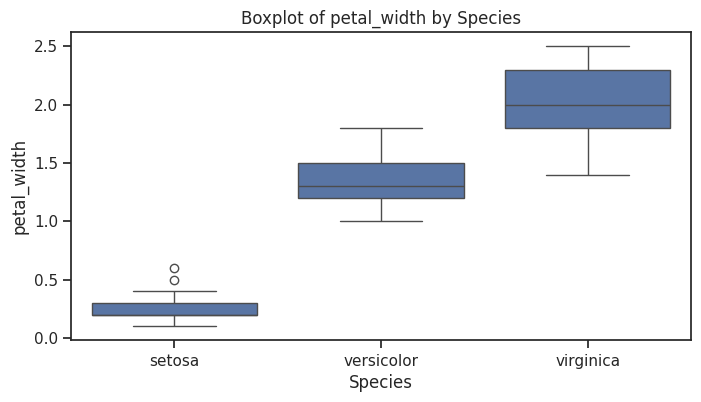

In [29]:
# Lấy danh sách các cột numeric
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    # Cài đặt kích thước cho mỗi biểu đồ
    plt.figure(figsize=(8, 4))

    # Vẽ boxplot so sánh biến numeric hiện tại theo từng loài (species)
    sns.boxplot(data=df, x='species', y=col)

    # Thêm tiêu đề và nhãn
    plt.title(f'Boxplot of {col} by Species')
    plt.xlabel('Species')
    plt.ylabel(col)

    # Hiển thị biểu đồ
    plt.show()

Đối với `sepal_length`, histogram thể hiện một phân phối có nhiều đỉnh (multimodal), và không có biểu hiện bị lệch quá nhiều (mặc dù hơi lệch phải đôi chút), nhưng nhìn chung là tập trung nhiều xung quanh giá trị `5.0`, khoảng `(5.5, 5.8)`, và `(6.3, 6.5)`. Dựa vào xấp xỉ PDF từ KDE, có thể thấy phân phối tiệm cận với hình chuông, nhưng phần giữa bị trải dài (bẹt). Ngoài ra, phân phối có đuôi ngắn, giảm dần đều về hai phía và không có cột nào nằm quá xa so với phần đông, điều này cho thấy biến `sepal_length` có thể có rất ít hoặc không có outlier. Nếu đối chiếu thêm với bảng tóm tắt `mean`, và `std` ở trên theo từng loài, và boxplot bên dưới, các khoảng này nằm trong các khoảng giá trị trung tâm (cụ thể là tiệm cận rất sát với trung vị - đường kẻ ngang giữa hộp) và khoảng tứ phân vị (thân hộp chứa 50% dữ liệu) của từng giống hoa riêng biệt. Ngoài ra, nếu nhìn kỹ hơn vào boxplot, ta thấy được mức độ overlap giữa các loài theo giá trị của `sepal_length` là rất ít, và các hộp nằm khá nối tiếp và sát nhau, điều này giúp lý giải cho phần giữa bị trải dài của hình chuông. Tổng kết lại, có thể nói biến này có khả năng phân loại giữa các loài của `species` ở mức khá tốt, có thể giảm tình trạng overfitting của mô hình.

Đối với `sepal_width`, histogram thể hiện một phân phối chỉ có duy nhất một đỉnh (unimodal) xung quanh giá trị `3.0`, và không có dấu hiệu bị lệch. Phần đuôi có xu hướng bị kéo dài ra hai bên cho thấy biến `sepal_width` có thể sẽ có outlier. Dựa vào đường CDF được xấp xỉ bằng KDE, ta còn có thể thấy nó tiệm cận với hình chuông của phân phối chuẩn. Giống với `sepal_length`, boxplot của từng loài không có sự overlap đáng kể, và nằm nối tiếp nhau, cho thấy khả năng phân loại ở mức khá tốt của `sepal_width`.

Đối với hai biến `petal_length`, và `petal_width`, histogram thể hiện chung một phân phối nhị đỉnh (bimodal), và cả hai đều có một khoảng bị trống, hay thưa ở giữa. Ngoài ra, đồ thị còn có một số cột thấp hơn đáng kể so với phần đông, thể hiện rằng biến này có thể có outlier. Đối chiếu với boxplot của cả hai biến theo từng loài, ta thấy được giữa các hộp với nhau hoàn toàn không có overlap và thực sự có một vài điểm outlier. Chung quy lại, hai biến này thể hiện khả năng phân loại ở mức rất tốt, nếu đưa vào mô hình phân loại, chúng sẽ đóng vai trò rất quan trọng giúp cải thiện hiệu suất một cách đáng kể cho mô hình.

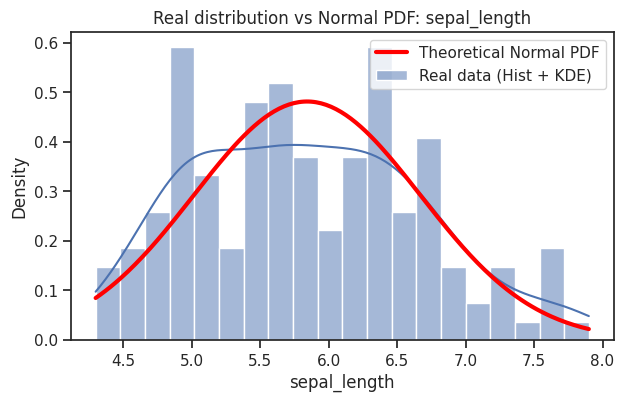

In [30]:
feature = "sepal_length"
x = df[feature].dropna()

mu = x.mean()
sigma = x.std()
n = len(x)

np.random.seed(42)
normal_sample = np.random.normal(loc=mu, scale=sigma, size=n)

x_grid = np.linspace(
    start=x.min(),
    stop=x.max(),
    num=200
)

normal_pdf = (
    1 / (sigma * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((x_grid - mu) / sigma) ** 2)
)

fig, ax = plt.subplots(figsize=(7, 4))

sns.histplot(
    x=x,
    bins=20,
    stat="density",
    kde=True,
    ax=ax,
    label="Real data (Hist + KDE)"
)

# Đổi sang màu đỏ rực rỡ và tăng độ dày để nổi bật hơn
ax.plot(
    x_grid,
    normal_pdf,
    label="Theoretical Normal PDF",
    color="red",
    linewidth=3,
    zorder=5
)

ax.set_title(f"Real distribution vs Normal PDF: {feature}")
ax.set_xlabel(feature)
ax.set_ylabel("Density")
ax.legend()

plt.show()

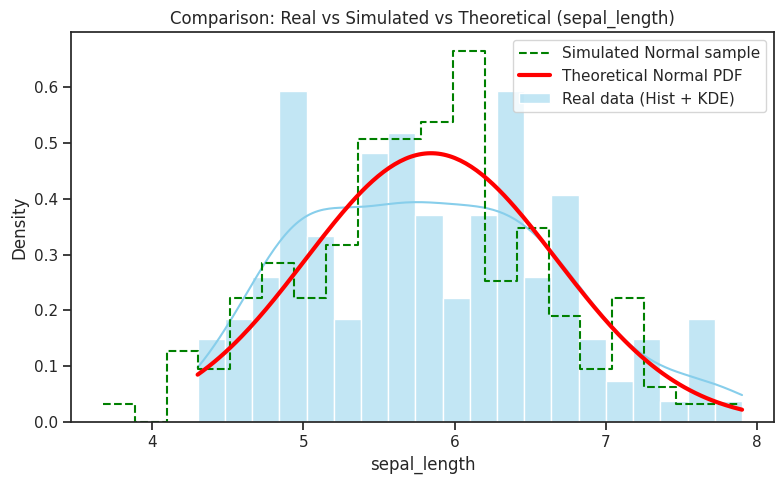

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    x=x,
    bins=20,
    stat="density",
    kde=True,
    ax=ax,
    label="Real data (Hist + KDE)",
    color="skyblue"
)

sns.histplot(
    x=normal_sample,
    bins=20,
    stat="density",
    element="step",
    fill=False,
    ax=ax,
    label="Simulated Normal sample",
    color="green",
    linestyle="--"
)

# Cập nhật đường PDF lý thuyết với màu đỏ đậm và độ dày lớn
ax.plot(
    x_grid,
    normal_pdf,
    label="Theoretical Normal PDF",
    color="red",
    linewidth=3,
    zorder=10
)

ax.set_title(f"Comparison: Real vs Simulated vs Theoretical ({feature})")
ax.set_xlabel(feature)
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

Dựa trên kết quả trực quan hóa so sánh giữa dữ liệu thực nghiệm (histogram `Real Data`), hàm mật độ xác suất lý thuyết (PDF) và mẫu mô phỏng từ phân phối chuẩn, có thể thấy mức độ trùng khớp (goodness-of-fit) là rất thấp. Vì vậy, việc áp đặt giả định phân phối chuẩn cho toàn bộ tập dữ liệu của biến `sepal_length` là không hợp lý và sẽ dẫn đến những sai lệch nghiêm trọng trong suy diễn thống kê.

Như đã trình bày ở phần diễn giải bên trên, bản chất của các biến định lượng trong tập dataset này là một mô hình hỗn hợp (mixture model), được cấu thành từ ba quần thể sinh học có các đặc trưng phân phối tương đối độc lập và không nhất thiết là đồng nhất với nhau. Điển hình là hai biến `petal_length` và `petal_width` thể hiện sự phân tách ranh giới rõ rệt giữa các loài, tạo nên một phân phối tổng thể đa đỉnh (multimodal) và uốn lượng như trên. Do đó, việc tính toán ước lượng các tham số tổng thể (như trung bình $\mu$ và phương sai $\sigma^2$) cho các biến này sẽ dẫn đến **hiện tượng sai lệch do gộp (aggregation bias)** và **ngụy biện sinh thái (ecological fallacy)**, và sẽ tạo ra những ước lượng tham số phi thực tế không đại diện cho bất kỳ quần thể thực tế nào. Chính vì vậy, mặc dù miền giá trị của biến `sepal_length` có sự chồng lấp (overlap) nhất định giữa ba loài, nhưng nhìn chung nó là không đáng kể và sự khác biệt về trung tâm phân phối vẫn đủ lớn để gây ra sự ước lượng tham số không hợp lý nếu ta vẫn tiếp tục đánh giá trung bình và phương sai một cách chung chung.

Tóm lại, đối với những biến định lượng có khả năng phân loại (discriminative power) từ mức khá tốt trở lên như trong dataset này, các chiến lược phân tích gộp là không phù hợp. Thay vào đó, ta cần áp dụng các kỹ thuật như kỹ thuật phân tầng (stratification) để bóc tách dữ liệu theo từng giống hoa và đánh giá dựa trên các phân phối có điều kiện của từng lớp (class-conditional distributions). Tương ứng, quy trình kiểm định giả thuyết cũng cần phải được chuyển hướng: thay vì kiểm định trên một tham số tổng thể tổng quát, ta cần kiểm định sự khác biệt giữa các trung bình nhóm (thông qua phân tích ANOVA, hoặc Independent $t$-test). Điều này không chỉ đảm bảo tính hợp lệ của các mô hình thống kê mà còn phản ánh chính xác bản chất sinh học cốt lõi của dữ liệu.

# Phần 3 — Phân tích đa biến & tương quan

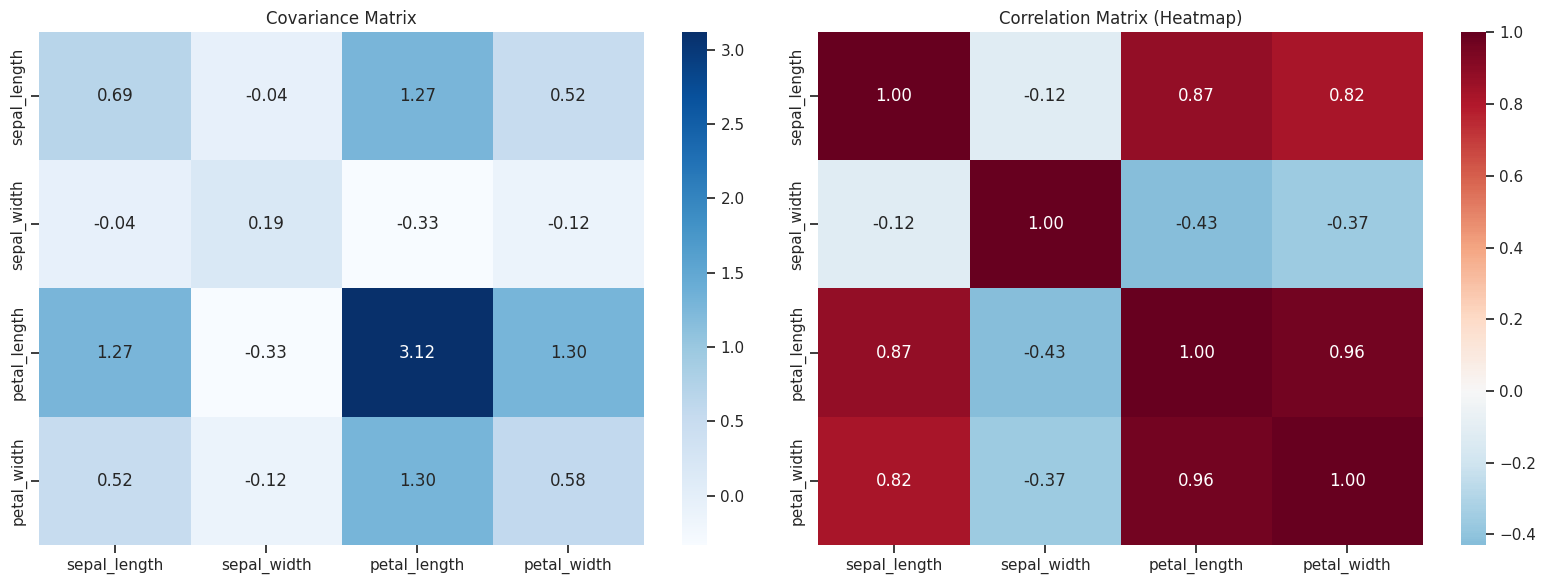

In [32]:
# 1. Tính toán ma trận hiệp phương sai và tương quan
cov_matrix = numeric_df.cov()
corr_matrix = numeric_df.corr()

# 2. Trực quan hóa
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap cho Ma trận Hiệp phương sai
sns.heatmap(
    cov_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=ax[0]
)
ax[0].set_title("Covariance Matrix")

# Heatmap cho Ma trận Tương quan
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=ax[1]
)
ax[1].set_title("Correlation Matrix (Heatmap)")

plt.tight_layout()
plt.show()

Dựa vào kết quả của heatmap trên, ta có thể thấy cặp biến tương quan thuận mạnh nhất là cặp `petal_length` và `petal_width` với hệ số là `0.96`, cho thấy một mối quan hệ tuyến tính rất mạnh giữa hai biến này. Ngoài ra ta còn các cặp tương quan rất mạnh khác là cặp `sepal_length` - `petal_length` (`0.87`), `petal_width` - `sepal_length` (`0.82`). Theo quy ước thông thường, những cặp biến có hệ số tương quan từ `0.7` hoặc `0.8` trở lên được gọi là hiện tượng đa cộng tuyến. Nói nôm na, các cặp biến đa cộng tuyến về mặt thống kê sẽ mang các thông tin về kết quả dự đoán gần như tương tự nhau, làm cho mô hình học máy trở nên nhiễu loạn và mất phương hướng. Để loại bỏ hiện tượng đa cộng tuyến, ta có thể dùng phương pháp loại bỏ trực tiếp, hoặc giảm chiều dữ liệu bằng PCA.

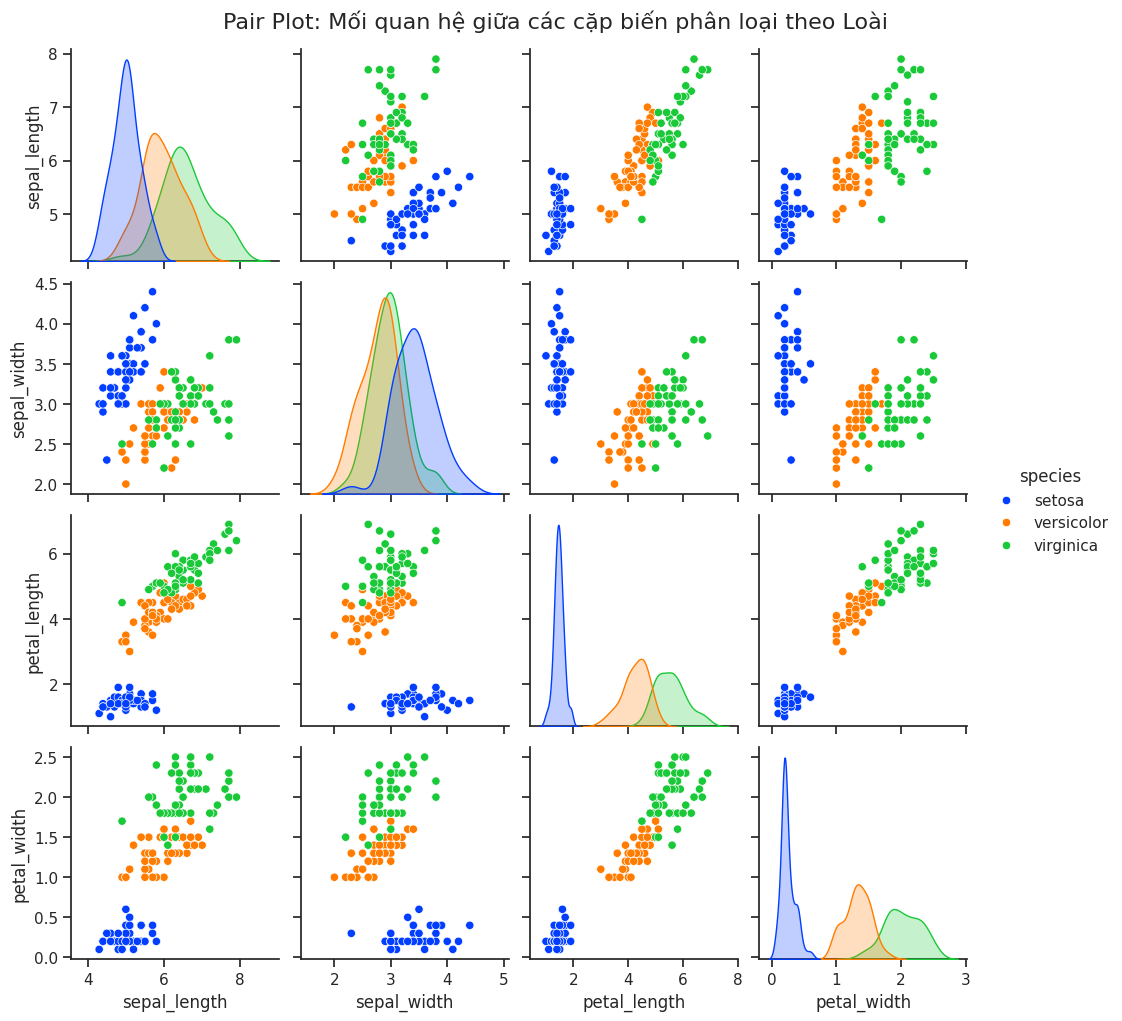

In [33]:
# Vẽ Pair Plot để xem xét mối quan hệ giữa các cặp biến và sự phân tách loài
sns.set_theme(style="ticks")
pair_plot = sns.pairplot(df, hue="species", palette="bright", diag_kind="kde")

pair_plot.fig.suptitle("Pair Plot: Mối quan hệ giữa các cặp biến phân loại theo Loài", y=1.02, fontsize=16)
plt.show()

Dựa trên biểu đồ Pair Plot, mối quan hệ song biến  giữa các đặc trưng về hình thái bộc lộ rõ rệt cấu trúc phân cụm của dữ liệu, đồng thời củng cố mạnh mẽ luận điểm về mô hình hỗn hợp (mixture model) đã được phân tích trước đó. Đáng chú ý nhất là cặp biến `petal_length` và `petal_width` thể hiện một tương quan tuyến tính thuận cực kỳ mạnh mẽ. Các điểm dữ liệu của cặp biến này phân bố dọc theo một trục chéo hẹp, cho thấy sự phát triển đồng thời và tỷ lệ thuận của kích thước cánh hoa. Sự tương quan này duy trì tính nhất quán cả trên bình diện tổng thể lẫn bên trong nội bộ từng quần thể (intra-class), tái khẳng định nguy cơ đa cộng tuyến (multicollinearity) nếu đưa đồng thời cả hai biến này vào cùng một mô hình thuật toán học máy tuyến tính.

Phân tích không gian đặc trưng qua các đồ thị phân tán (scatter plots) cho thấy năng lực phân loại rất sâu sắc của các biến `petal`. Quần thể hoa `setosa` (được biểu thị bằng màu xanh dương) hình thành một cụm hoàn toàn biệt lập, tập trung ở vùng giá trị thấp trong tất cả các mặt phẳng tọa độ có sự xuất hiện của `petal_length` hoặc `petal_width`. Sự cô lập tuyệt đối này khẳng định sự tồn tại của một biên giới phân loại rõ ràng: loài `setosa` có thể được phân tách ra khỏi hai loài còn lại. Trong khi đó, quần thể `versicolor` (màu cam) và `virginica` (màu xanh lá) có xu hướng phân bố tiếp nối nhau và xảy ra sự chồng lấn nhẹ ở các vùng biên, cho thấy các mô hình phân loại sẽ cần những decision boundary phức tạp hơn hoặc sự kết hợp đa chiều để phân biệt chính xác hai loài này.

Một hiện tượng thống kê đặc biệt quan trọng có thể quan sát được khi phân tích cặp biến `sepal_length` và `sepal_width`. Nếu nhìn nhận trên toàn bộ tập dữ liệu dưới dạng gộp (tức không xét riêng ra theo bất kỳ loài hoa nào mà gộp chung lại), đám mây điểm dữ liệu có xu hướng lan rộng và gợi ý một mối tương quan nghịch yếu. Tuy nhiên, khi nhìn dưới lăng kính phân tầng (class-conditional) dựa trên màu sắc phân loại, đồ thị bộc lộ rõ **Simpson's Paradox**. Cụ thể, bên trong nội bộ từng quần thể sinh học riêng biệt (thể hiện rõ nhất ở cụm `setosa`), chiều dài và chiều rộng đài hoa thực chất lại có mối tương quan thuận. Hiện tượng này minh chứng sống động cho "ngụy biện sinh thái" (ecological fallacy); nó khẳng định rằng việc bỏ qua cấu trúc phân lớp ẩn của dữ liệu không chỉ làm mất đi thông tin phân loại/dự đoán, mà còn làm biến dạng và đảo ngược hoàn toàn bản chất tương quan thực sự của các đặc trưng sinh lý học.

# Phần 4 — Xác suất & Định lý Bayes

In [34]:

P_B = 0.01
P_not_B = 1 - P_B

P_pos_given_B = 0.99
P_pos_given_not_B = 0.05

P_pos = (
    P_pos_given_B * P_B
    + P_pos_given_not_B * P_not_B
)

P_B_given_pos = P_pos_given_B * P_B / P_pos

print(f"P(+): {P_pos:.4f}")
print(f"P(B | +): {P_B_given_pos:.4f}")
print(f"P(B | +) as percentage: {P_B_given_pos:.2%}")

P(+): 0.0594
P(B | +): 0.1667
P(B | +) as percentage: 16.67%


,prevalence,posterior_probability
0,0.001,0.019435
1,0.002,0.038165
2,0.003,0.056229
3,0.004,0.073661
4,0.005,0.090494


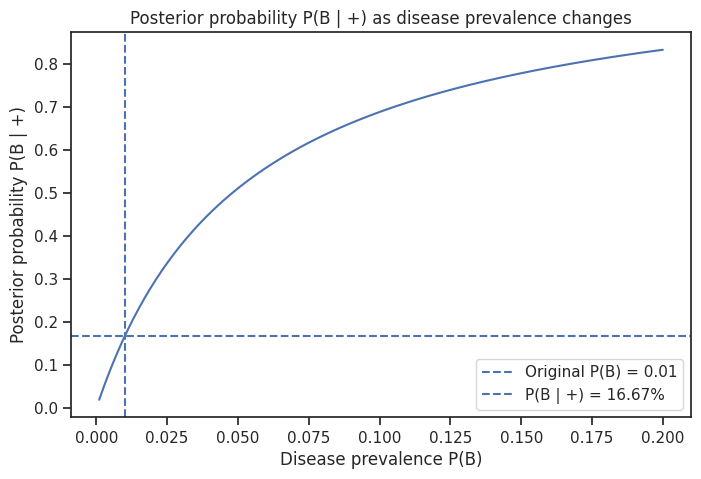

In [35]:
prevalence_values = np.linspace(
    start=0.001,
    stop=0.2,
    num=200
)

posterior_values = (
    P_pos_given_B * prevalence_values
    / (
        P_pos_given_B * prevalence_values
        + P_pos_given_not_B * (1 - prevalence_values)
    )
)

bayes_curve_df = pd.DataFrame({
    "prevalence": prevalence_values,
    "posterior_probability": posterior_values,
})

display(bayes_curve_df.head())

fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=bayes_curve_df,
    x="prevalence",
    y="posterior_probability",
    ax=ax
)

ax.set_title("Posterior probability P(B | +) as disease prevalence changes")
ax.set_xlabel("Disease prevalence P(B)")
ax.set_ylabel("Posterior probability P(B | +)")

# Mark the original prevalence P(B)=0.01
ax.axvline(
    P_B,
    linestyle="--",
    label="Original P(B) = 0.01"
)

ax.axhline(
    P_B_given_pos,
    linestyle="--",
    label=f"P(B | +) = {P_B_given_pos:.2%}"
)

ax.legend()
plt.show()

Kết quả $P(B | +) ≈ 0.1667$, tức khoảng $16.67\%$. Điều này có vẻ phản trực giác vì xét nghiệm có độ nhạy rất cao $P(+ | B) = 0.99$. Tuy nhiên, vì bệnh rất hiếm với $P(B) = 0.01$, nghĩa là số người không mắc bệnh lớn hơn rất nhiều so với số người mắc bệnh. Vì vậy, dù tỉ lệ dương tính giả chỉ là $0.05$, số lượng dương tính giả vẫn có thể lớn hơn số lượng dương tính thật. Đây là hiện tượng base-rate effect.

## Bonus: Spam classifier using Naive Bayes

In [36]:
emails = pd.DataFrame({
    "text": [
        "win money now",
        "free prize win",
        "cheap money offer",
        "meeting schedule today",
        "project meeting update",
        "family dinner today",
    ],
    "label": [
        "spam",
        "spam",
        "spam",
        "not_spam",
        "not_spam",
        "not_spam",
    ]
})

display(emails)

,text,label
0,win money now,spam
1,free prize win,spam
2,cheap money offer,spam
3,meeting schedule today,not_spam
4,project meeting update,not_spam
5,family dinner today,not_spam


In [37]:
keywords = [
    "win", "money", "free", "prize", "cheap", "offer",
    "meeting", "project", "family", "dinner", "today"
]

for word in keywords:
    emails[word] = emails["text"].str.contains(word).astype(int)

feature_df = emails[["text", "label"] + keywords]
display(feature_df)

,text,label,win,money,free,prize,cheap,offer,meeting,project,family,dinner,today
0,win money now,spam,1,1,0,0,0,0,0,0,0,0,0
1,free prize win,spam,1,0,1,1,0,0,0,0,0,0,0
2,cheap money offer,spam,0,1,0,0,1,1,0,0,0,0,0
3,meeting schedule today,not_spam,0,0,0,0,0,0,1,0,0,0,1
4,project meeting update,not_spam,0,0,0,0,0,0,1,1,0,0,0
5,family dinner today,not_spam,0,0,0,0,0,0,0,0,1,1,1


Tính prior probability

In [38]:
class_counts = emails["label"].value_counts()

P_spam = class_counts["spam"] / len(emails)
P_not_spam = class_counts["not_spam"] / len(emails)

print(f"P(spam): {P_spam:.4f}")
print(f"P(not_spam): {P_not_spam:.4f}")

P(spam): 0.5000
P(not_spam): 0.5000


In [39]:
def estimate_word_probability(word, target_label, alpha=1):
    """
    Estimate P(word appears | target_label) using Laplace smoothing.

    Parameters
    ----------
    word : str
        Keyword column name.
    target_label : str
        Either "spam" or "not_spam".
    alpha : int or float
        Laplace smoothing strength.

    Returns
    -------
    float
        Smoothed conditional probability P(word | target_label).
    """
    subset = emails[emails["label"] == target_label]

    word_count = subset[word].sum()
    total_docs = len(subset)

    # Binary feature smoothing: numerator + alpha, denominator + 2 * alpha
    return (word_count + alpha) / (total_docs + 2 * alpha)


conditional_probs = pd.DataFrame({
    "word": keywords,
    "P(word|spam)": [
        estimate_word_probability(word, "spam")
        for word in keywords
    ],
    "P(word|not_spam)": [
        estimate_word_probability(word, "not_spam")
        for word in keywords
    ],
})

display(conditional_probs)

,word,P(word|spam),P(word|not_spam)
0,win,0.6,0.2
1,money,0.6,0.2
2,free,0.4,0.2
3,prize,0.4,0.2
4,cheap,0.4,0.2
5,offer,0.4,0.2
6,meeting,0.2,0.6
7,project,0.2,0.4
8,family,0.2,0.4
9,dinner,0.2,0.4


Demo kết quả

In [40]:
def predict_spam_probability(email_text):
    """
    Compute P(spam | email_text) using a simple Bernoulli Naive Bayes model.

    Parameters
    ----------
    email_text : str
        Input email text.

    Returns
    -------
    dict
        Posterior probabilities for spam and not_spam.
    """
    email_text = email_text.lower()

    spam_score = P_spam
    not_spam_score = P_not_spam

    for word in keywords:
        word_appears = word in email_text

        p_word_given_spam = estimate_word_probability(word, "spam")
        p_word_given_not_spam = estimate_word_probability(word, "not_spam")

        if word_appears:
            spam_score *= p_word_given_spam
            not_spam_score *= p_word_given_not_spam
        else:
            spam_score *= (1 - p_word_given_spam)
            not_spam_score *= (1 - p_word_given_not_spam)

    normalizer = spam_score + not_spam_score

    return {
        "email": email_text,
        "P(spam|email)": spam_score / normalizer,
        "P(not_spam|email)": not_spam_score / normalizer,
        "prediction": "spam" if spam_score > not_spam_score else "not_spam",
    }


test_emails = [
    "win free money now",
    "project meeting today",
    "cheap prize offer",
]

predictions = pd.DataFrame([
    predict_spam_probability(email)
    for email in test_emails
])

display(predictions)

,email,P(spam|email),P(not_spam|email),prediction
0,win free money now,0.986301,0.013699,spam
1,project meeting today,0.007752,0.992248,not_spam
2,cheap prize offer,0.934307,0.065693,spam
